List of pigments:

* Phthalo	Blue (Green Shade), PB 15:4, Copper Phthalocyanine
* Quinacridone Magenta, PR 122, Quinacridone
* Hansa Yellow, PY 74, Benzimidazolone Yellow
* Titanium White, PW 6, Titanium Dioxide

http://www.goldenpaints.com/products/colors/heavy-body


# Setup

In [1]:
# Attempt to create a perceptually uniform mixing space by applying a bias to the
# interpolation parameter.
PERCEPTUAL_MIX = False

In [2]:
%reload_ext autoreload
%autoreload 1
%aimport pigments

In [3]:
# @title Imports
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import onnxruntime as ort
import os
import pigments

# Mixing

In [4]:
# @title Setup pigments
pg = pigments.Pigments(pigments.load_config_from_json("config.json"))

🚀 Accelerating using Apple Silicon GPU (MPS)


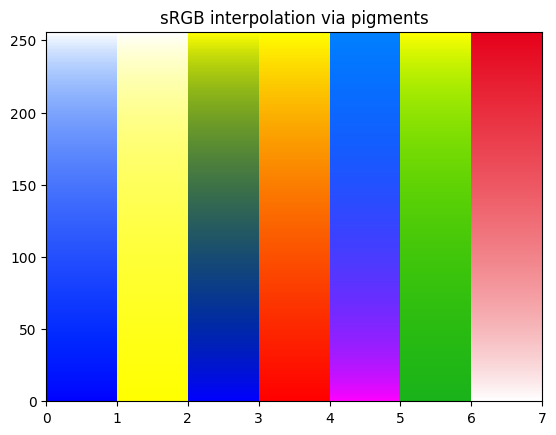

In [5]:
# @title Interpolation from RGB
rgb1 = [
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 1.0],
    [0.1, 0.7, 0.1],
    [1.0, 1.0, 1.0],
]
rgb2 = [
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 0.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.5, 1.0],
    [1.0, 1.0, 0.0],
    [0.9, 0.0, 0.1],
]

patchCount = 256
ig, ax = plt.subplots()

for k in range(len(rgb1)):
    c1 = pg.unmix(rgb1[k])
    r1 = rgb1[k] - pg.mix(c1)

    c2 = pg.unmix(rgb2[k])
    r2 = rgb2[k] - pg.mix(c2)

    # Only used with PERCEPTUAL_MIX set to True
    linear_rgb1 = np.array([i ** 2.2 for i in rgb1[k]])
    linear_rgb2 = np.array([i ** 2.2 for i in rgb2[k]])
    l1 = np.dot(linear_rgb1, [0.2126, 0.7152, 0.0722]) ** 0.5
    l2 = np.dot(linear_rgb2, [0.2126, 0.7152, 0.0722]) ** 0.5
    bias = l2 / (l1 + l2)

    for j in range(patchCount):
        t = j / (patchCount - 1.0)
        t_perceptual = t / ((1 / bias - 2) * (1 - t) + 1)

        rgb = pg.latent_lerp(c1, r1, c2, r2, t_perceptual if PERCEPTUAL_MIX else t)

        ax.add_patch(
            patches.Rectangle(
                (k, j), 1, 1,
                facecolor=np.clip(rgb, 0.0, 1.0)
            )
        )

ax.set_xlim(0, len(rgb1))
ax.set_ylim(0, patchCount)

plt.title('sRGB interpolation via pigments')
plt.show()

# MLP Mixing

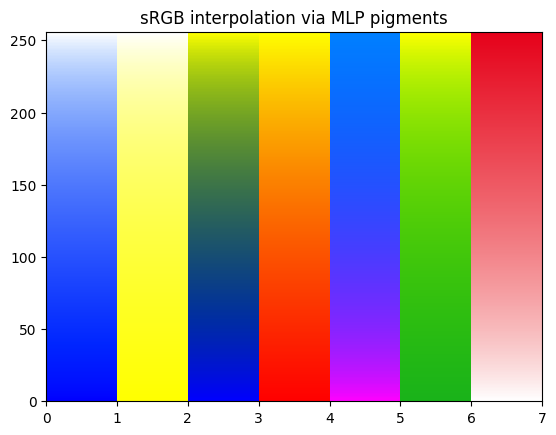

In [6]:
data_config = pigments.load_data_config_from_json('data_config.json')

if os.path.exists(data_config.model_path_onnx):
    session = ort.InferenceSession(data_config.model_path_onnx)
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    patchCount = 256
    ig, ax = plt.subplots()

    for k in range(len(rgb1)):
        input_data = np.array([rgb1[k]], dtype=np.float32)
        results = session.run([output_name], {input_name: input_data})
        concentrations = np.clip(results[0][0], 0.0, 1.0)

        c1 = np.append(concentrations, 1.0 - concentrations.sum())
        r1 = rgb1[k] - pg.mix(c1)

        input_data = np.array([rgb2[k]], dtype=np.float32)
        results = session.run([output_name], {input_name: input_data})
        concentrations = np.clip(results[0][0], 0.0, 1.0)

        c2 = np.append(concentrations, 1.0 - concentrations.sum())
        r2 = rgb2[k] - pg.mix(c2)

        # Only used with PERCEPTUAL_MIX set to True
        linear_rgb1 = np.array([i ** 2.2 for i in rgb1[k]])
        linear_rgb2 = np.array([i ** 2.2 for i in rgb2[k]])
        l1 = np.dot(linear_rgb1, [0.2126, 0.7152, 0.0722]) ** 0.5
        l2 = np.dot(linear_rgb2, [0.2126, 0.7152, 0.0722]) ** 0.5
        bias = l2 / (l1 + l2)

        for j in range(patchCount):
            t = j / (patchCount - 1.0)
            t_perceptual = t / ((1 / bias - 2) * (1 - t) + 1)

            rgb = pg.latent_lerp(c1, r1, c2, r2, t_perceptual if PERCEPTUAL_MIX else t)

            ax.add_patch(
                patches.Rectangle(
                    (k, j), 1, 1,
                    facecolor=np.clip(rgb, 0.0, 1.0)
                )
            )

    ax.set_xlim(0, len(rgb1))
    ax.set_ylim(0, patchCount)

    plt.title('sRGB interpolation via MLP pigments')
    plt.show()